In [ ]:
from functools import partial
import os
os.environ["OPENBLAS_NUM_THREADS"] = "12"

import sax
from simphony.libraries import siepic
from ctypes import Array
import numpy as np, matplotlib.pyplot as plt
from pyparsing import Union
from simphony.circuit import Circuit
from simphony.simulation import SampleModeSimulation
from simphony.simulation.sample_mode import SampleModeSimulationParameters, SampleModeSimulation
from simphony.circuit.components import SampleModeComponent
from simphony.signals import SampleModeOpticalSignal
import jax
import jax.numpy as jnp
from commpy.filters import rrcosfilter
from scipy.signal import upfirdn 
from scipy.integrate import solve_ivp

In [9]:
# def minmax(u):
#     return (u - u.min())/(u.max() - u.min())
# key = jax.random.PRNGKey(0)
# key2 = jax.random.PRNGKey(1)
# sigma, rho, beta = 10.0, 28.0, 8/3

# def lorenz(t, xyz):
#     x, y, z = xyz
#     return [sigma*(y - x), x*(rho - z) - y, x*y - beta*z]

# N_coarse = N
# dtt = 0.05
# upsample = 1

# T = dtt * (N_coarse - 1)

# dt_fine = dtt / upsample
# t_fine = np.arange(0.0, T + 1e-12, dt_fine)

# sol_fine = solve_ivp(
#     lorenz, (0.0, T), (0., 1., 1.05),
#     method="RK45", max_step=dt_fine, t_eval=t_fine
# )
# x_f, y_f, z_f = sol_fine.y

# signal  = minmax(x_f)
# signal2 = minmax(y_f)
# y       = minmax(z_f)
# combined_sig = signal + signal2
# combined_sig = minmax(combined_sig)*jnp.pi
# def rrc_shape(symbols, h, sps):
#     x = upfirdn(h.astype(np.float32), np.asarray(symbols, np.float32), up=sps)
#     d = (len(h) - 1) // 2
#     return jnp.asarray(x[d:d + len(symbols)*sps], dtype=jnp.float32)
# sps = 50
# beta = 0.5
# span = 4
# _, h = rrcosfilter(span*sps+1, beta, 1.0, sps)
# phase_wave1 = rrc_shape(combined_sig,h, sps)
for i in range(4):

    def GM(wl: Union[float, Array] = 1.55):
        def load_sdict_npz(fname):
            d = np.load(fname)
            wls = d["wavelengths"]
            S = {}
            for k in d.files:
                if k == "wavelengths": continue
                # keys like "S_out3_in5"
                _, to_p, from_p = k.split("_", 2)
                S[(to_p, from_p)] = np.squeeze(d[k])
            return wls, S
        w_i, Sp = load_sdict_npz("gm_real_sdict_1p50_1p60um_1000pts.npz")
        return Sp


    class StreamingCombSourceTime(SampleModeComponent):
        optical_ports = ["o0"]

        def __init__(self, base_wavelengths, scale=1.0):
            bw = jnp.asarray(base_wavelengths, jnp.float32).reshape(-1)
            self.base  = bw
            self.M     = int(bw.shape[0])
            self.scale = jnp.float32(scale)

        def sample_mode_initial_state(self, simulation_parameters):
            phi = jnp.zeros((self.M,), jnp.float32)
            t_idx = jnp.int32(0)
            return (phi, t_idx)

        @partial(jax.jit, static_argnums=(0,))
        def sample_mode_step(self, inputs, state, simulation_parameters):
            phi, t_idx = state
            A = (self.scale * jnp.exp(1j * phi).astype(jnp.complex64))[:, None]
            wls = self.base.astype(jnp.float32)
            out = {"o0": SampleModeOpticalSignal(amplitude=A, wavelength=wls)}
            return out, (phi, t_idx + jnp.int32(1))
        
    class OpticalModulatorTime(SampleModeComponent):
        optical_ports = ["o0", "o1"]

        def __init__(self, *, length=1.0, operating_wl=1.55e-6, effective_index=2.4,
                    group_index=4.2, mod_signal=0.0):
            self.length = float(length)
            self.operating_wl = float(operating_wl)
            self.effective_index = float(effective_index)
            self.group_index = float(group_index)
            self.mod_signal = jnp.asarray(mod_signal)

        def sample_mode_initial_state(self, simulation_parameters):
            return jnp.int32(0)

        def sample_mode_step(self, inputs, state, simulation_parameters):
            a0 = inputs["o0"].amplitude  # forward field (W,M)
            a1 = inputs["o1"].amplitude  # reverse field (if any)
            lam = inputs["o0"].wavelength

            if a0.ndim == 1: a0 = a0[:, None]
            if a1.ndim == 1: a1 = a1[:, None]
            dtype = a0.dtype
            

            phase_t = self.mod_signal[state]
            

            coeff = jnp.exp(1j * (phase_t)).astype(dtype)
            out0 = SampleModeOpticalSignal(jnp.zeros_like(a1), lam)
            out1 = SampleModeOpticalSignal(a0 * coeff, lam)

            return {"o0": out0, "o1": out1}, state + 1

    netlist = {
        "instances": {
            "laser1":"laser1",
            "gm":"GM",
            
        },
        
        "connections": {
            # "laser1,o0":"wg1,o0"
            f"laser1,o0": f"gm,in{i}",
        
        },
        "ports": {
            "o0": "gm,out0",
            "o1": "gm,out1",
            "o2": "gm,out2",
            "o3": "gm,out3",
            "o4": "gm,out4",
            "o5": "gm,out5",
            "o6": "gm,out6",
            "o7": "gm,out7",
        }
    }

    models = {
        "laser1": StreamingCombSourceTime,
        "GM": GM,
    }
    wavelengths = jnp.linspace(1.50e-6, 1.60e-6, 50, jnp.float32)
    dt = 1e-14
    t = jnp.arange(0, 100000)*dt
    print(len(t))
    settings = {
        "laser1": {
        "base_wavelengths": wavelengths,
        "scale":jnp.sqrt(1.0),
        },
        "gm":{
            "max_order":150
            },
    }

    circuit = Circuit(netlist=netlist, models=models)
    sim = SampleModeSimulation(circuit = circuit)
    simulation_parameters = SampleModeSimulationParameters(
        optical_baseband_wavelengths=wavelengths,
        num_time_steps=int(len(t)), sampling_period=dt)

    results50 = sim.run(simulation_parameters=simulation_parameters, settings=settings)
    jax.block_until_ready(results50)
    plt.plot(np.abs(results50["o2"]["output"].amplitude[:20000,0,0])**2)
    plt.show()
    points = {}
    for j in range(8):
        points[f"o{j}"] = results50[f"o{j}"]["output"].amplitude[20000,:,0]
    plt.plot(np.abs(points["o2"])**2)
    plt.show()
    np.savez(f"gm_output_signal_{i}_point.npz", points = points)
#20 minutes using just one max_order_model

100000
Initial state for laser1 computed
Initial state for gm computed
Initial state for _optical_termination0 computed
Initial state for _optical_termination1 computed
Initial state for _optical_termination2 computed
Initial state for _optical_termination3 computed
Initial state for _optical_termination4 computed
Initial state for _optical_termination5 computed
Initial state for _optical_termination6 computed
Initial state for _optical_termination7 computed
Initial state for _optical_termination8 computed
Initial state for _optical_termination9 computed
Initial state for _optical_termination10 computed
Initial state for _optical_termination11 computed
Initial state for _optical_termination12 computed
Initial state for _optical_termination13 computed
Initial state for _optical_termination14 computed
Starting simulation...


: 

Plotting only 4 inputs: ['gm_output_signal_0.npz', 'gm_output_signal_1.npz']


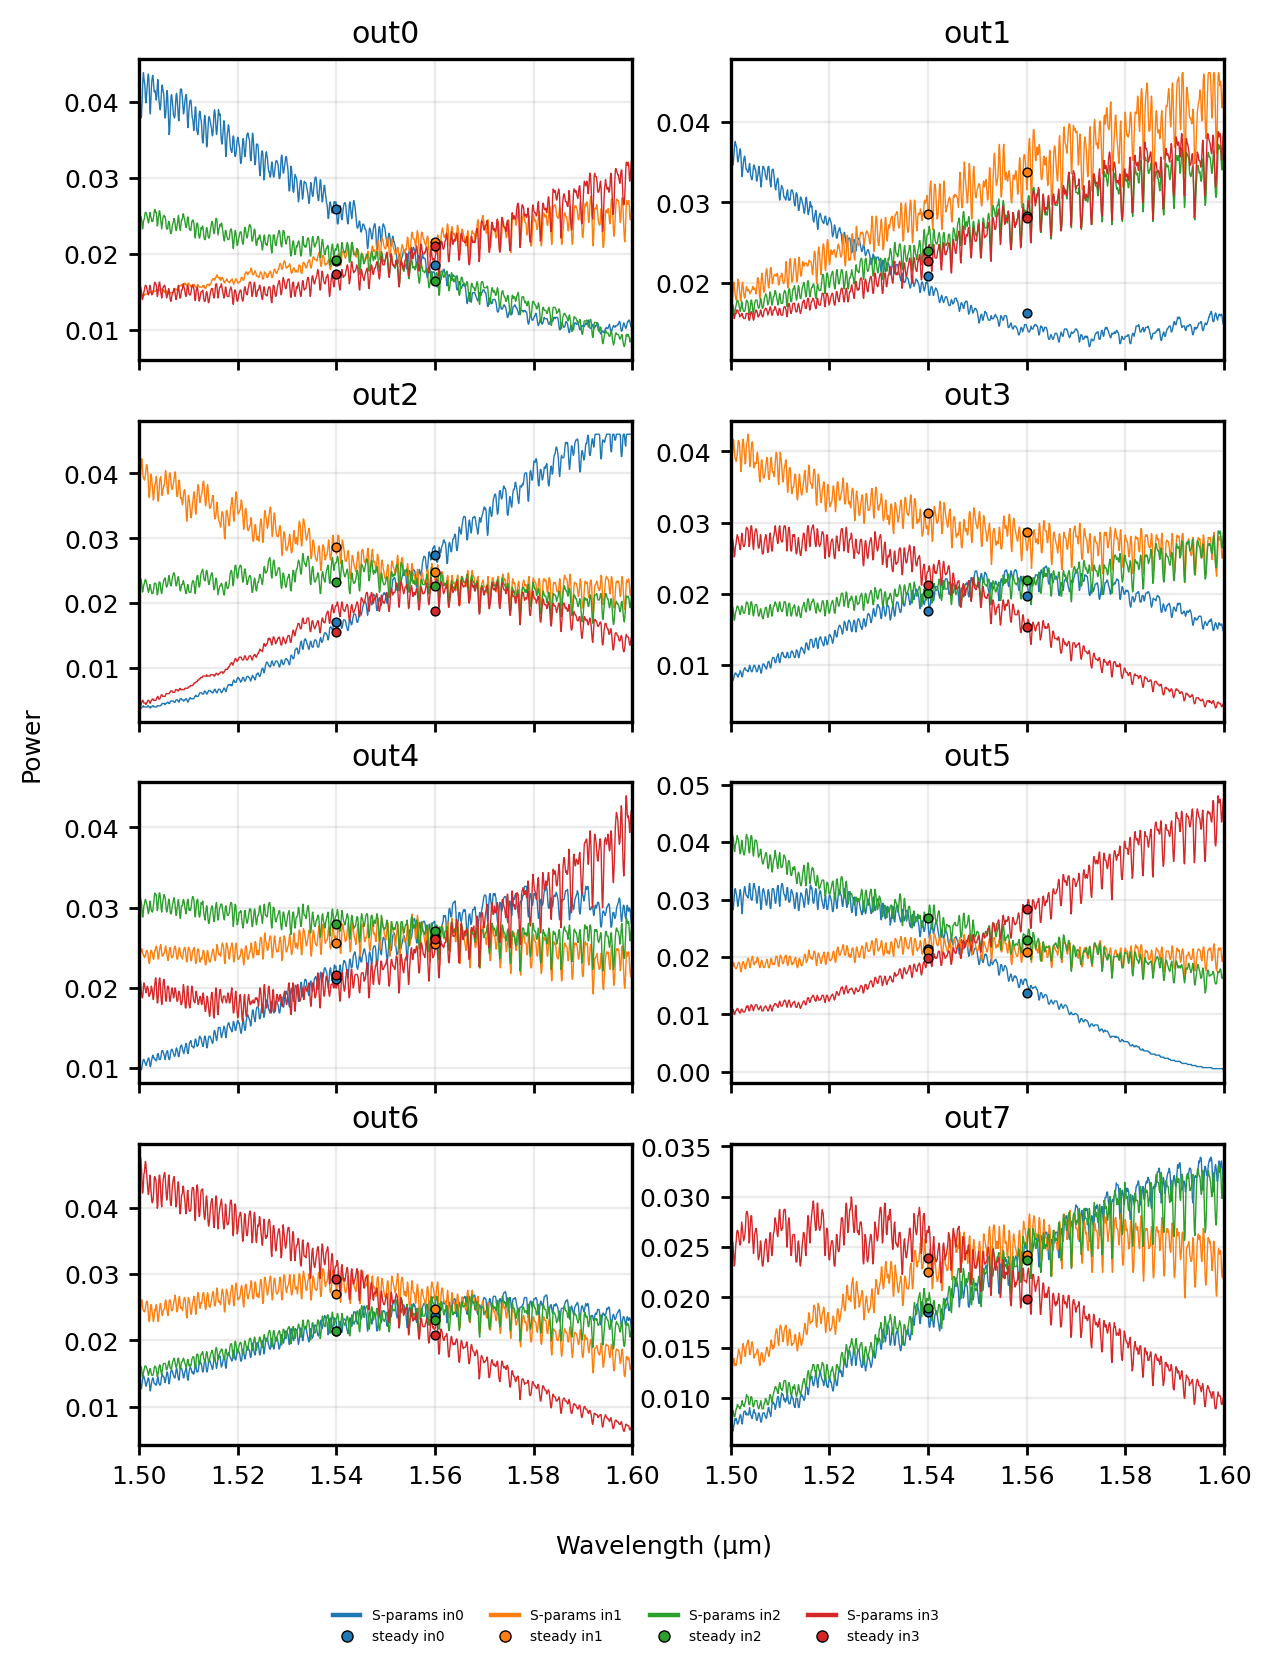

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import glob

def load_sdict_npz(fname):
    d = np.load(fname)
    wls = d["wavelengths"]
    S = {}
    for k in d.files:
        if k == "wavelengths":
            continue
        _, to_p, from_p = k.split("_", 2)
        S[(to_p, from_p)] = np.squeeze(d[k])
    return wls, S


# ------------------------------------------------------
# LOAD ONLY FIRST 2 gm_output_signal_*.npz FILES
# ------------------------------------------------------

signal_files = sorted(glob.glob("gm_output_signal_*.npz"))
signals = [np.load(f, allow_pickle=True)["signal"].item()
           for f in signal_files[:4]]
num_inputs = len(signals)

print(f"Plotting only {num_inputs} inputs: {signal_files[:2]}")


# ------------------------------------------------------
# STYLE
# ------------------------------------------------------

mpl.rcParams.update({
    "figure.dpi": 200,
    "axes.linewidth": 1.2,
    "font.size": 9,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
    "lines.linewidth": 1.4,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Colors & markers for 6 inputs
colors  = ["tab:blue", "tab:orange","tab:green","tab:red","tab:purple","tab:brown", "tab:pink","tab:gray"]

markers = ["o", "s", "^", "D", "v", "P"]  # circle for in0, square for in1, triangle for in2


# ------------------------------------------------------
# WAVELENGTH POINTS (two channels)
# ------------------------------------------------------

wl_points = [1.54, 1.56]  # microns
wl_idx    = [0, 1]          # amplitude indices
# OPTION B — mapping is:
#   1.525 µm → hollow
#   1.575 µm → filled


# ------------------------------------------------------
# PORT INFO
# ------------------------------------------------------

w_i, Sp = load_sdict_npz("gm_real_sdict_1p50_1p60um_1000pts.npz")

out_keys  = [f"out{i}" for i in range(8)]
data_keys = [f"o{i}"   for i in range(8)]
in_keys   = [f"in{i}"  for i in range(num_inputs)]


# ------------------------------------------------------
# FIGURE SETUP
# ------------------------------------------------------

fig, axes = plt.subplots(4, 2, figsize=(7, 9), sharex=True)
axes = axes.flatten()


# ------------------------------------------------------
# LEGEND ENTRIES (only 2 inputs)
# ------------------------------------------------------

legend_entries = []

for i in range(num_inputs):
    c = colors[i]

    line = plt.Line2D([], [], color=c, linewidth=1.6,
                      label=f"S-params {in_keys[i]}")

    # OPTION B legend markers:

    mk_filled = plt.Line2D([], [], marker="o", markersize=4,
                           markerfacecolor=c,
                           markeredgecolor="black", markeredgewidth=0.5,
                           linestyle="None",
                           label=f"steady {in_keys[i]}")   # filled

    legend_entries.extend([line, mk_filled])


# ------------------------------------------------------
# MAIN LOOP — PLOT
# ------------------------------------------------------

for ax_id, (ok, dk) in enumerate(zip(out_keys, data_keys)):
    ax = axes[ax_id]

    for i, results in enumerate(signals):
        c = colors[i]
        in_key = in_keys[i]

        S = Sp[(ok, in_key)]
        ax.plot(w_i, np.abs(S)**2, color=c, linewidth=0.5)

        amp = results[dk]["output"].amplitude

        # ---- filled (575) ----
        ss_val_filled = amp[20000, 0, 0]   # index 0 is actually 1.575 µm
        ss_pow_filled = np.abs(ss_val_filled)**2
        ax.scatter(1.56, ss_pow_filled,
                   marker="o", s=10,
                   color=c, edgecolor="black",
                   linewidth=0.5, zorder=10)

        # ---- hollow (525) ----
        ss_val_hollow = amp[20000, 1, 0]   # index 1 is actually 1.525 µm
        ss_pow_hollow = np.abs(ss_val_hollow)**2
        ax.scatter(1.54, ss_pow_hollow,
                   marker="o", s=10,
                   color=c, edgecolor="black",
                   linewidth=0.5, zorder=10)

    ax.set_title(ok, pad=6)


# ------------------------------------------------------
# LABELS & LIMITS
# ------------------------------------------------------

for ax in axes:
    ax.set_xlim(1.50, 1.60)

fig.text(0.5, 0.05, "Wavelength (µm)", ha="center")
fig.text(0.04, 0.5, "Power", va="center", rotation="vertical")


# ------------------------------------------------------
# LEGEND
# ------------------------------------------------------

fig.legend(handles=legend_entries,
           frameon=False,
           fontsize=5,
           loc="lower center",ncols=4)


plt.show()


Loaded: ['gm_output_signal_0_point.npz', 'gm_output_signal_1_point.npz', 'gm_output_signal_2_point.npz', 'gm_output_signal_3_point.npz']
Number of inputs = 4


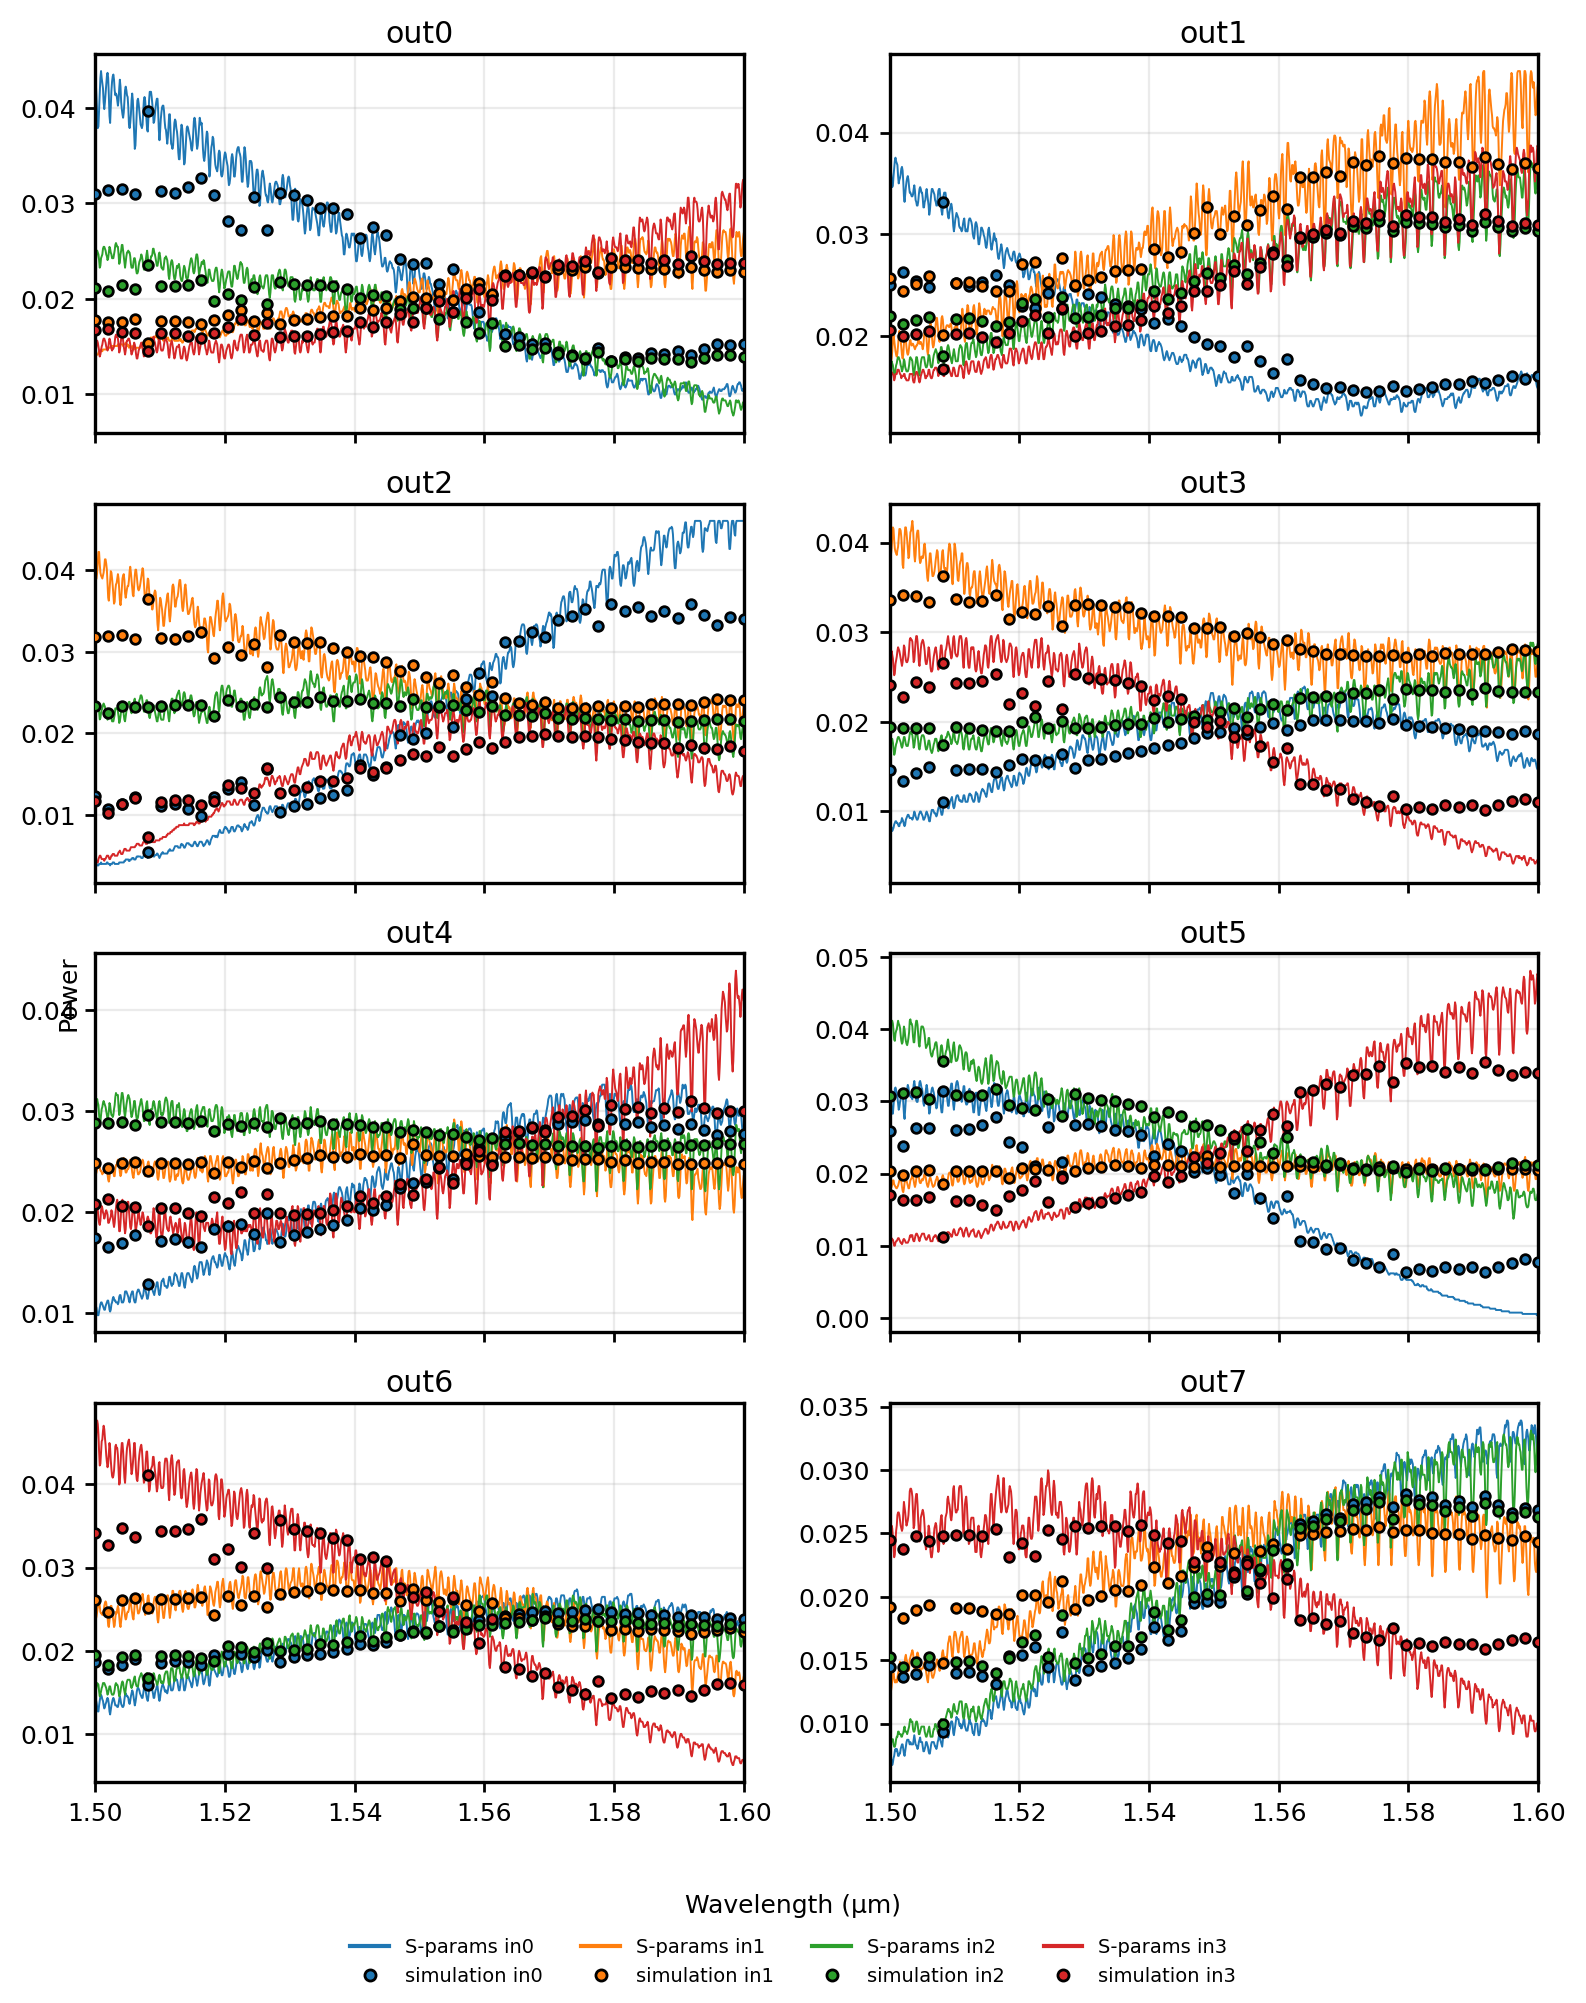

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import glob


def load_sdict_npz(fname):
    d = np.load(fname)
    wls = d["wavelengths"]
    S = {}
    for k in d.files:
        if k == "wavelengths":
            continue
        _, to_p, from_p = k.split("_", 2)
        S[(to_p, from_p)] = np.squeeze(d[k])
    return wls, S


signal_files = sorted(glob.glob("gm_output_signal_*_point.npz"))
print("Loaded:", signal_files)

signals = []
for f in signal_files:
    dat = np.load(f, allow_pickle=True)["points"].item()
    signals.append(dat)

num_inputs = len(signals)
print("Number of inputs =", num_inputs)

mpl.rcParams.update({
    "figure.dpi": 200,
    "axes.linewidth": 1.2,
    "font.size": 9,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
    "lines.linewidth": 1.4,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

colors  = ["tab:blue","tab:orange","tab:green","tab:red",
           "tab:purple","tab:brown","tab:pink","tab:gray"]

w_i, Sp = load_sdict_npz("gm_real_sdict_1p50_1p60um_1000pts.npz")

out_keys  = [f"out{i}" for i in range(8)]
data_keys = [f"o{i}"   for i in range(8)]
in_keys   = [f"in{i}"  for i in range(num_inputs)]

# original wavelength grid used in the sim
wavelengths = np.linspace(1.50, 1.60, 50)
# flipped for plotting to match S-parameter direction
wavelengths_plot = wavelengths[::-1]

fig, axes = plt.subplots(4, 2, figsize=(8, 10), sharex=True)
axes = axes.flatten()

legend_entries = []
for i in range(num_inputs):
    c = colors[i]
    line = plt.Line2D([], [], color=c, linewidth=1.5,
                      label=f"S-params {in_keys[i]}")
    mk = plt.Line2D([], [], marker="o", markersize=4,
                    markerfacecolor=c, markeredgecolor="black",
                    linestyle="None",
                    label=f"simulation {in_keys[i]}")
    legend_entries.extend([line, mk])

for ax_id, (ok, dk) in enumerate(zip(out_keys, data_keys)):
    ax = axes[ax_id]

    for i in range(num_inputs):
        c = colors[i]
        in_key = in_keys[i]

        S = Sp[(ok, in_key)]
        ax.plot(w_i, np.abs(S)**2, color=c, linewidth=0.7)

        amp_array = signals[i][dk]         # shape (50,)
        power = np.abs(amp_array)**2

        # flip the x-positions
        ax.scatter(wavelengths_plot, power,
                   color=c, edgecolor="black",
                   s=12, marker="o", zorder=10)

    ax.set_title(ok, pad=4)

for ax in axes:
    ax.set_xlim(1.50, 1.60)

fig.text(0.5, 0.04, "Wavelength (µm)", ha="center")
fig.text(0.04, 0.5, "Power", va="center", rotation="vertical")

fig.legend(handles=legend_entries,
           frameon=False, fontsize=7,
           loc="lower center", ncols=4)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()
